# Tech Challenge — Fase 1

**Tema:** Saúde da mulher — classificação de câncer de mama (maligno vs benigno)

**Objetivo:** atender às entregas técnicas do PDF — EDA, pré-processamento, dois ou mais modelos, métricas e explicabilidade.

## 1. Contexto e definição do problema

Redes de saúde feminina precisam de **triagem rápida** para priorizar e detectar antecipadamente casos de risco de câncer de mama. Este trabalho não substitui o médico: é um **apoio à decisão** baseado em padrões históricos dos dados.

## 2. Carregamento e exploração inicial dos dados

In [ ]:
import pandas as pd

df = pd.read_csv("../data/data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [20]:
df.shape

(569, 33)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

### *Quais são os possíveis valores da variável alvo?*

In [8]:
df['diagnosis'].unique()

<StringArray>
['M', 'B']
Length: 2, dtype: str

### *Sendo assim:*

- **Variáveis Características:** medidas numéricas (ex.: raio, textura, perímetro).
- **Variável Target (o que queremos descobrir):** classe `M -> maligno` ou `B -> benigno`.

### *Quantos registros existem em cada classe?*

In [11]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

### *Existe algum valor faltando no dataset?*

In [9]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

### Dicionário de atributos

- **id**: Identificador único da amostra.
- **diagnosis**: Diagnóstico original no dataset (`M` = maligno, `B` = benigno).
- **radius_mean**: Raio médio dos núcleos celulares.
- **texture_mean**: Textura média dos núcleos celulares.
- **perimeter_mean**: Perímetro médio dos núcleos celulares.
- **area_mean**: Área média dos núcleos celulares.
- **smoothness_mean**: Suavidade média da borda dos núcleos.
- **compactness_mean**: Compacidade média dos núcleos.
- **concavity_mean**: Concavidade média das formas dos núcleos.
- **concave points_mean**: Número médio de pontos côncavos nos núcleos.
- **symmetry_mean**: Simetria média dos núcleos.
- **fractal_dimension_mean**: Dimensão fractal média dos núcleos.
- **radius_se**: Erro padrão do raio dos núcleos.
- **texture_se**: Erro padrão da textura dos núcleos.
- **perimeter_se**: Erro padrão do perímetro dos núcleos.
- **area_se**: Erro padrão da área dos núcleos.
- **smoothness_se**: Erro padrão da suavidade dos núcleos.
- **compactness_se**: Erro padrão da compacidade dos núcleos.
- **concavity_se**: Erro padrão da concavidade dos núcleos.
- **concave points_se**: Erro padrão do número de pontos côncavos.
- **symmetry_se**: Erro padrão da simetria dos núcleos.
- **fractal_dimension_se**: Erro padrão da dimensão fractal.
- **radius_worst**: Maior valor observado de raio nos núcleos.
- **texture_worst**: Maior valor observado de textura nos núcleos.
- **perimeter_worst**: Maior valor observado de perímetro nos núcleos.
- **area_worst**: Maior valor observado de área nos núcleos.
- **smoothness_worst**: Maior valor observado de suavidade nos núcleos.
- **compactness_worst**: Maior valor observado de compacidade nos núcleos.
- **concavity_worst**: Maior valor observado de concavidade nos núcleos.
- **concave points_worst**: Maior valor observado de pontos côncavos nos núcleos.
- **symmetry_worst**: Maior valor observado de simetria nos núcleos.
- **fractal_dimension_worst**: Maior dimensão fractal observada nos núcleos.

Observação: a coluna Unnamed: 32 pode ser descartada, pois não contém valores relevantes e a coluna id também por ser somente identificação

In [22]:
df_limpo = df.drop(
    columns=[
        'id',
        'Unnamed: 32'
    ]
)

df_limpo.shape

(569, 31)

### *O conjunto de dados está balanceado entre tumores benignos e malignos?*

In [24]:
df_limpo['diagnosis'].value_counts(normalize=True) * 100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

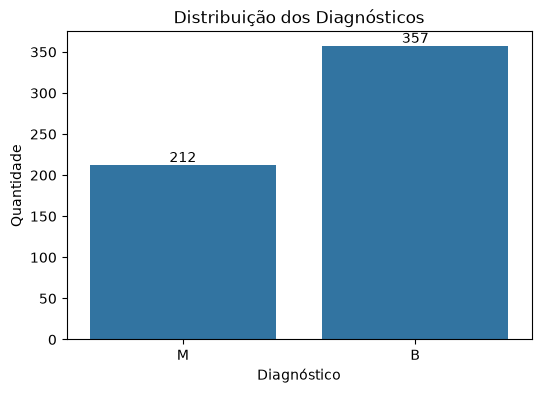

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x='diagnosis'
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribuição dos Diagnósticos')
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade')

plt.show()

A análise da variável alvo mostrou que o conjunto de dados possui 357 amostras classificadas como benignas (62,7%) e 212 amostras classificadas como malignas (37,3%). Embora exista uma predominância da classe benigna, a diferença entre as classes não é muito grande para caracterizar um desbalanceamento severo. Dessa forma, inicialmente não será necessária a aplicação de técnicas de balanceamento.

### *As características apresentam grande variabilidade entre as amostras?*

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


#

### *Os tumores malignos apresentam características geométricas maiores que os benignos?*

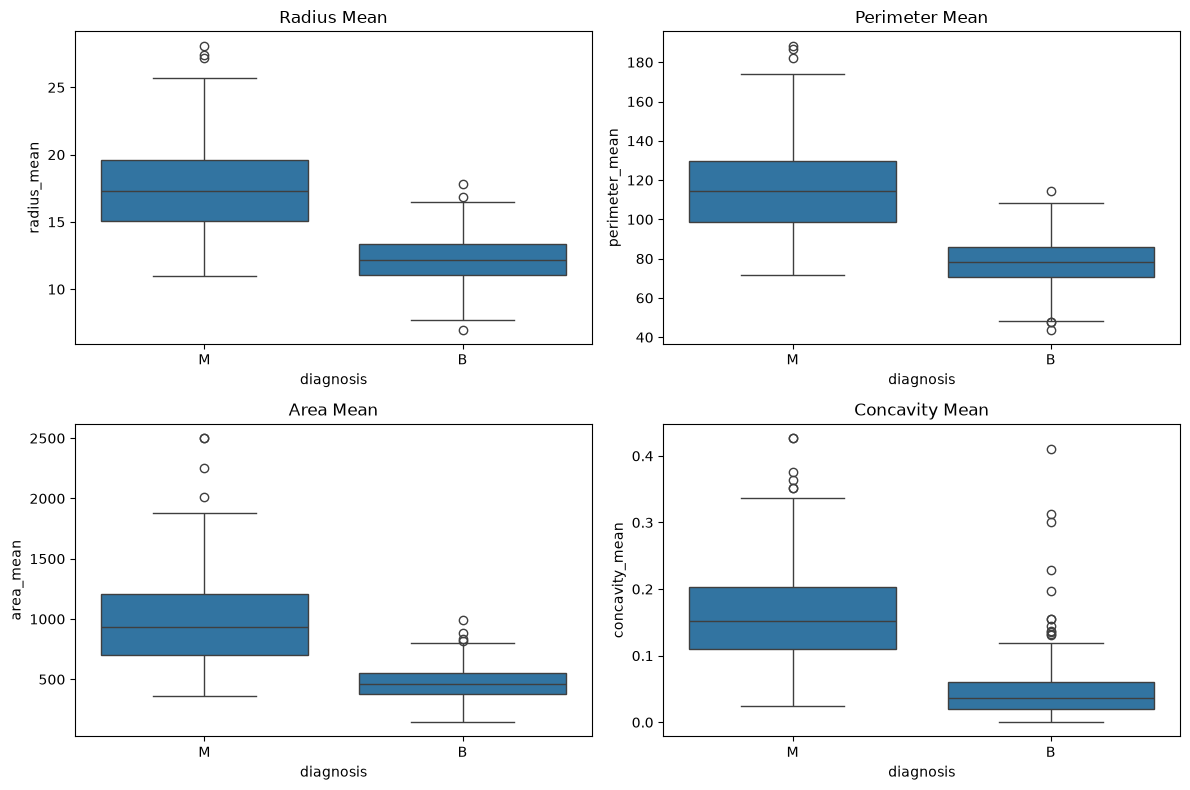

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x='diagnosis', y='radius_mean', ax=axes[0,0])
axes[0,0].set_title('Radius Mean')

sns.boxplot(data=df, x='diagnosis', y='perimeter_mean', ax=axes[0,1])
axes[0,1].set_title('Perimeter Mean')

sns.boxplot(data=df, x='diagnosis', y='area_mean', ax=axes[1,0])
axes[1,0].set_title('Area Mean')

sns.boxplot(data=df, x='diagnosis', y='concavity_mean', ax=axes[1,1])
axes[1,1].set_title('Concavity Mean')

plt.tight_layout()
plt.show()

Observa-se que tumores malignos apresentam valores medianos significativamente superiores para raio, perímetro e área. A reduzida sobreposição entre os grupos sugere que essas características possuem forte potencial discriminatório e devem ser consideradas no treinamento dos modelos.

### *As distribuições das características são diferentes entre tumores benignos e malignos?*

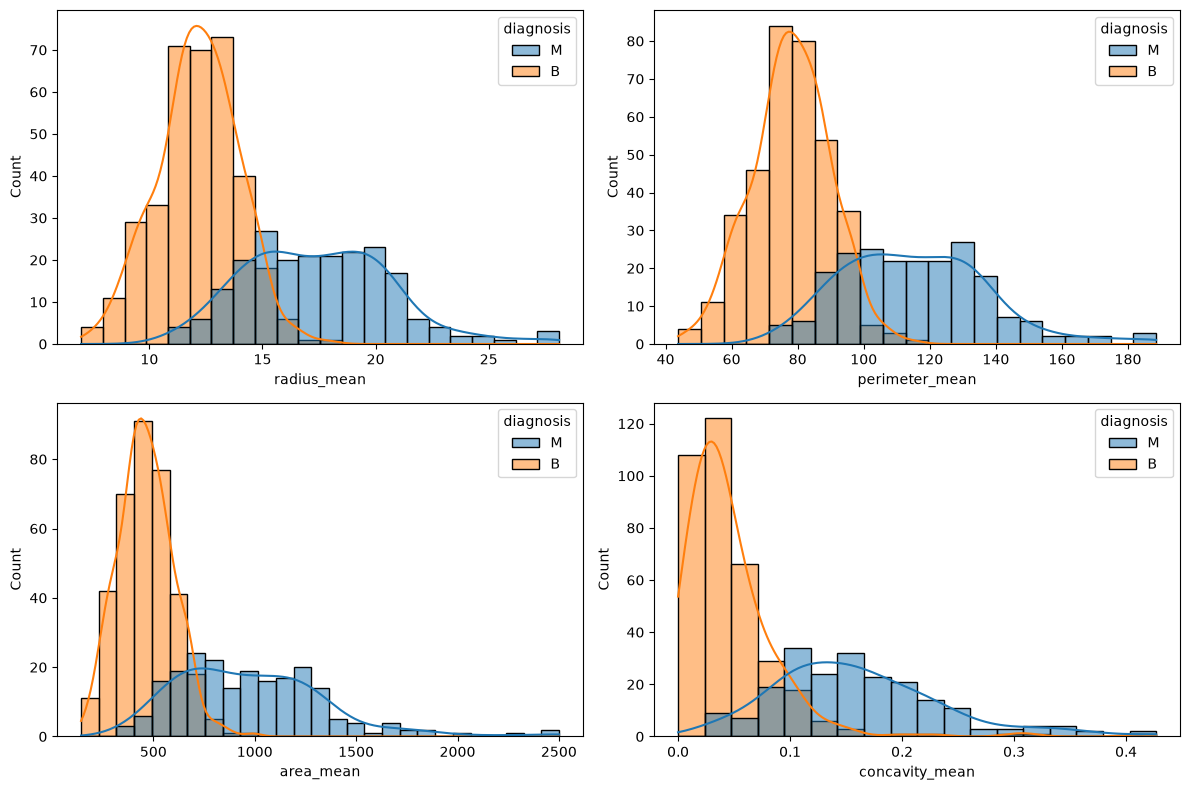

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.histplot(
    data=df,
    x='radius_mean',
    hue='diagnosis',
    kde=True,
    ax=axes[0,0]
)

sns.histplot(
    data=df,
    x='perimeter_mean',
    hue='diagnosis',
    kde=True,
    ax=axes[0,1]
)

sns.histplot(
    data=df,
    x='area_mean',
    hue='diagnosis',
    kde=True,
    ax=axes[1,0]
)

sns.histplot(
    data=df,
    x='concavity_mean',
    hue='diagnosis',
    kde=True,
    ax=axes[1,1]
)

plt.tight_layout()
plt.show()

A análise dos boxplots mostra que tumores classificados como malignos apresentam, em geral, valores mais elevados para raio médio (radius_mean), perímetro médio (perimeter_mean), área média (area_mean) e concavidade média (concavity_mean) quando comparados aos tumores benignos.

Observa-se também que as medianas dos grupos encontram-se claramente separadas, especialmente para as variáveis relacionadas ao tamanho do tumor (raio, perímetro e área), indicando que essas características possuem potencial poder discriminatório para os modelos de classificação.

## 3. Análise de correlação

## 4. Pré-processamento e separação treino/teste

## 5. Modelagem — três algoritmos

## 6. Explicabilidade — importância das variáveis e SHAP

### *Análise da variável alvo*

A variável alvo do estudo é diagnosis, responsável por indicar o diagnóstico do tumor analisado. Foram identificadas duas classes distintas:

M (Maligno): tumor maligno;
B (Benigno): tumor benigno.

A distribuição das classes apresentou 357 amostras benignas e 212 amostras malignas, totalizando 569 registros. Apesar da predominância da classe benigna, o conjunto de dados não apresenta um desbalanceamento severo, permitindo a aplicação de algoritmos de classificação sem necessidade imediata de técnicas de balanceamento.


A coluna id é apenas um identificador e não possui valor preditivo para o diagnóstico.


- **Métrica prioritária sugerida:** **recall** da classe maligna — errar um caso maligno (falso negativo) costuma ser mais grave que um falso positivo.

## 7. Discussão crítica